## Model Evaluation and Refinement

Model Evaluation tells us how well our model performs in the real world. So far we have been using in-sample evaluation which tells us how well 
our model fits the data already given to train it. It does not give us an estimate of how well the trained model can predict new data. 
The solution is to split our data, and use the in-sample data or training data to train the model. The rest of the data, called test data, 
is used as out-of-sample data. This data is then used to approximate how the model performs in the real world.

Usually the larger portion data is used for training and the smaller part is used for testing. We use the training set to build a model 
and discover predictive relationships. We then use the testing set to evaluate model performance.

Separating the dataset into Training and Testing data sets is an important part of model evaluation. This is usually done by separating the larger portion of the data for training, and the smaller set for testing.

* use the train_test_split() function from scikit-learn package to split the data accordingly.
* this function randomly splits a dataset into training and testing subsets.

### Generalization Performance
* Generalization Error is a measure of how well our data does at predicting previously unseen data.
* The error we obtain using out testing data is an approximation of this error.
* When we compare the predicted result using the in-sample data vs the out-of-sample data, we can see the difference representing Generalization Error.
* Using a lot of data for training can gives a more accurate means of determining how well the model perform in the real world, but the precision of the performance will be lower.
* When we repeatedly use a larger set of data for training and testing, the model will be more accurate but each cycle will have different results, and the differences in the results is known as generalization error.
* If we use smaller dataset for training and testing, the model accuracy will be lowered, but differences in results will be less, and hence lower generalization error.

### Cross Validation
* To avoid the above said problems, we use Cross Validation.
* The full dataset is divided equally into equally sized group call fold.
* Some of the fold can be used as training set, and the remaining folds will be used as test set.
* For example in a 4 folds split, we can use 3 folds for training the model, and the remaining 1 fold for tesing.
* Then we can swap the folds for training and testing over several iterations.
* In the end, we can take the average of the results as the estimated out-of-sample error.
* We use the cross_val_score() function from sklearn.model_selection to help us do all the above computation.
* The function takes 4 parameters:
    * estimator - specify our model for this parameter
    * x - specify our x values predicting variable dataset
    * y - specify the y values of the target result dataset
    * cv - specify the number of folds
* The function returns RCross, which is an array of scores from the iteration it performs depending on the number folds.
* We can calculate the mean of the Cross Validation error, RCross.mean().
* We can also calculate the Std.Deviation, RCross.std().


In [1]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

df = pd.read_csv('clean_df_Laptop.csv', header=0, index_col=0).select_dtypes(include=np.number)  # only include numeric columns
df.head()

,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb
0,4,2,1,5,35.56,0.551724,8,256,1.60,978,14.000000,3.52800
1,3,1,1,3,39.62,0.689655,4,256,2.20,634,15.598425,4.85100
2,3,1,1,7,39.62,0.931034,8,256,2.20,946,15.598425,4.85100
3,4,2,1,5,33.78,0.551724,8,128,1.22,1244,13.299213,2.69010
4,4,2,1,7,39.62,0.620690,8,256,1.91,837,15.598425,4.21155


In [2]:
# Task 1 : Using Cross validation to improve the model

# Divide the dataset into x_data and y_data parameters. Here y_data is the "Price" attribute, and x_data has all other attributes in the data set.
y_data = df['Price']
x_data = df.drop('Price', axis=1)

# Split the data set into training and testing subests such that you reserve 10% of the data set for testing purposes.
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1) # using 10% of the data size for testing
print(f"test data size: {x_test.shape[0]}")
print(f"train data size: {x_train.shape[0]}")

# Create a single variable linear regression model using "CPU_frequency" parameter. Print the R^2 value of this model for the training and testing subsets.
lm = LinearRegression()
lm.fit(x_train[['CPU_frequency']],y_train)
print(f"train data score: {lm.score(x_train[['CPU_frequency']], y_train)}") # 15%
print(f"test  data score: {lm.score(x_test[['CPU_frequency']], y_test)}")   # -6.5%

# Run a 4-fold cross validation on the model and print the mean value of R^2 score along with its standard deviation.
Rcross = cross_val_score(lm, x_train[['CPU_frequency']], y_train, cv=4)
print(f"The Cross Validated model's mean (train dataset) of R^2 is {Rcross.mean()}, and the std deviation is {Rcross.std()}") # 12% / 8.3%


Rcross

test data size: 24
train data size: 214
train data score: 0.14829792099817973
test  data score: -0.06599437350393789
The Cross Validated model's mean (train dataset) of R^2 is 0.1273881801955502, and the std deviation is 0.08317058010912029


array([-0.00664011,  0.21261413,  0.12677435,  0.17680436])

### Important conceptual notes:
We have use a single feature simple linear regression model, and train it with the training dataset. Then we check its R^2 score with both 
the training and test dataset and found that there is a vast gap indicating our model is underfitted. This implies our model is too 
generalized or simple for our data. At this point we need to fix the model by either using more features or use a curve model. We confirm 
it again using cross validation on the model and confirmed with the R^2 mean value. There is really no need to continue validating with 
the test dataset.

* Steps to follow when evaluating a model:
    1. Check the Training Score:
        * If it's low (Underfitting), add more features or try a non-linear model.
    2. Check Test Score:
        * If Training Score is high but Test Score is low (Overfitting), simplify the model or use regularization.
    3. Cross-Validation:
        * Use this to confirm that your "good" results aren't just due to a lucky split of the data.
        

Text(0.5, 1.0, 'R^2 Using Test Data')

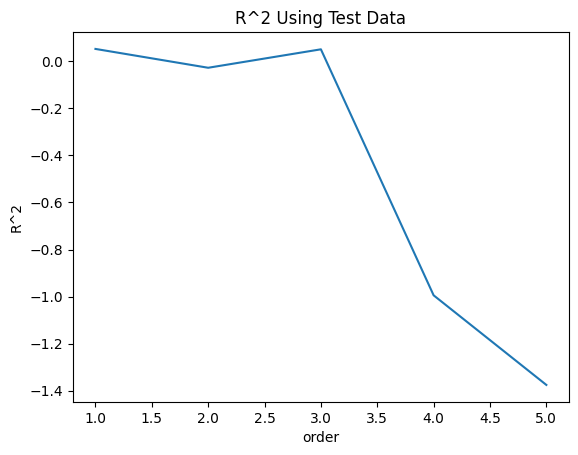

In [3]:
# Task 2: Overfitting

# Split the data set into training and testing components again, this time reserving 50% of the data set for testing.
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.50, random_state=0)

# To identify the point of overfitting the model on the parameter "CPU_frequency", you'll need to create polynomial features using the single attribute. 
# You need to evaluate the R^2 scores of the model created using different degrees of polynomial features, ranging from 1 to 5. Save this set of values of R^2 score as a list.
lr = LinearRegression()
Rsqu_test = []
order = [1, 2, 3, 4, 5]
for n in order:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(x_train[['CPU_frequency']])
    x_test_pr  = pr.fit_transform(x_test[['CPU_frequency']])    
    lr.fit(x_train_pr, y_train)
    Rsqu_test.append(lr.score(x_test_pr, y_test))


# Plot the values of R^2 scores against the order. Note the point where the score drops.
plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
# the score drop at order = 3.0




100%|██████████| 999/999 [00:01<00:00, 546.60it/s, Test Score=0.423, Train Score=0.669]


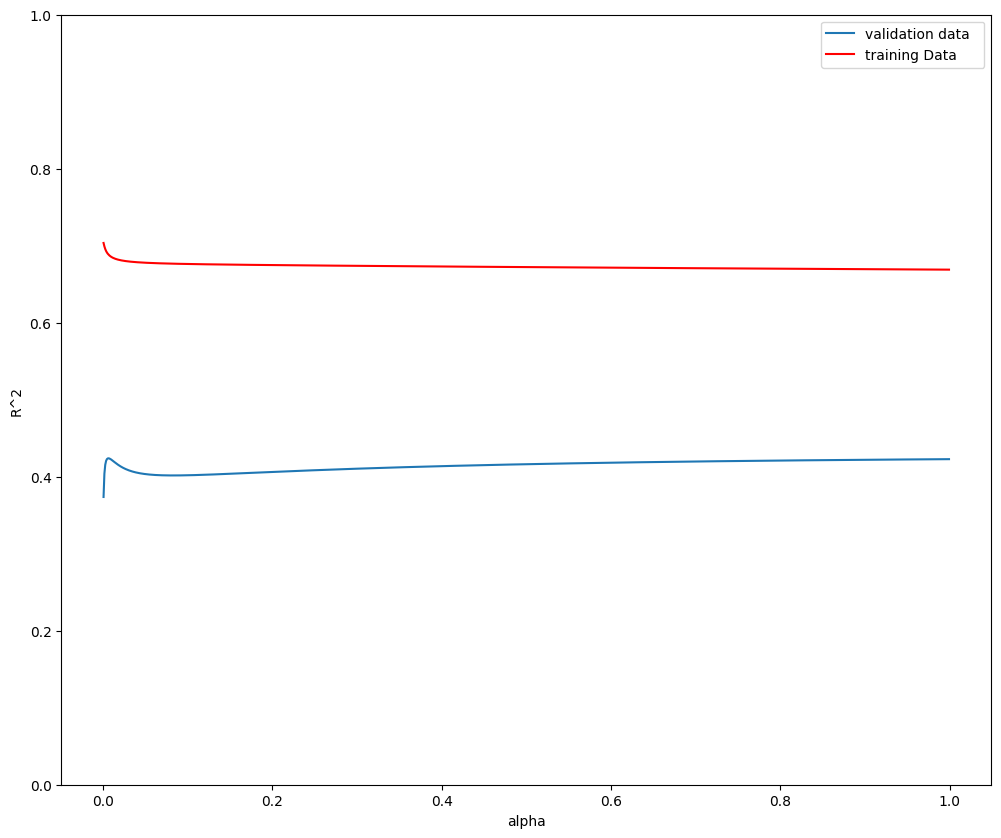

In [4]:
# Task 3 : Ridge Regression

# Now consider that you have multiple features, i.e. 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU' and 'Category'. 
# Create a polynomial feature model that uses all these parameters with degree=2. Also create the training and testing attribute sets.

pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']])
x_test_pr  = pr.fit_transform( x_test[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']])

# Create a Ridge Regression model and evaluate it using values of the hyperparameter alpha ranging from 0.001 to 1 with increments of 0.001. 
# Create a list of all Ridge Regression R^2 scores for training and testing data. 
Rsqu_test = []
Rsqu_train = []
Alpha = np.arange(0.001,1,0.001)
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)
    
    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})

    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)


# plotting out the value of R-square for different alphas:
width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.ylim(0,1)
plt.legend()




In [5]:
# Task 4: Grid Search¶

# Using the raw data and the same set of features as used above, use GridSearchCV to identify the value of alpha for which the model performs best. 
# Assume the set of alpha values to be used as {0.0001, 0.001, 0.01, 0.1, 1, 10}

parameters = [{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}]

# Create a Ridge instance and run Grid Search using a 4 fold cross validation.
RR = Ridge()
Grid = GridSearchCV(RR, parameters, cv=4)

# Fit the Grid Search to the training data.
Grid.fit(x_train[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']], y_train)

# Print the R^2 score for the test data using the estimator that uses the derived optimum value of alpha.
BestRR = Grid.best_estimator_
print(f"Best fit alpha: {Grid.best_params_['alpha']}") # the best fit alpha is stored in this object
print(f"Score (test data): {BestRR.score(x_test[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']], y_test):.2f}")




Best fit alpha: 10
Score (test data): 0.30
